   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

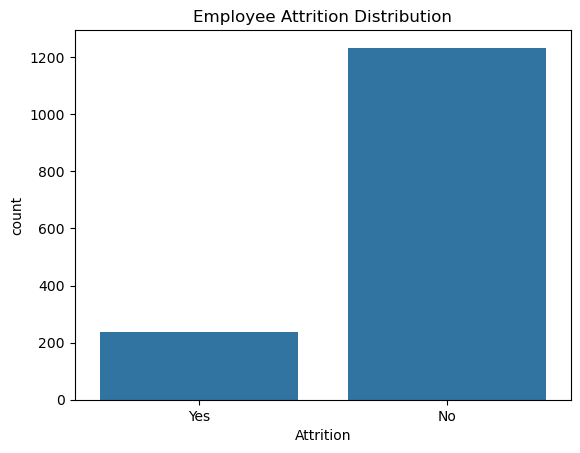

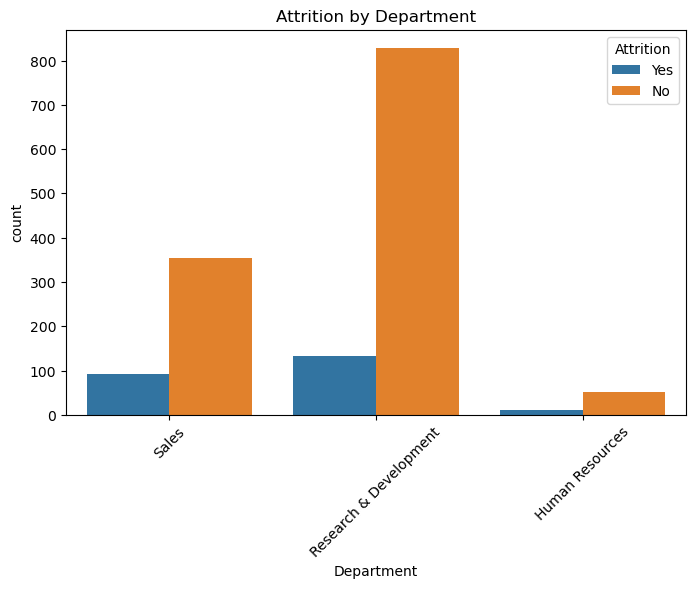

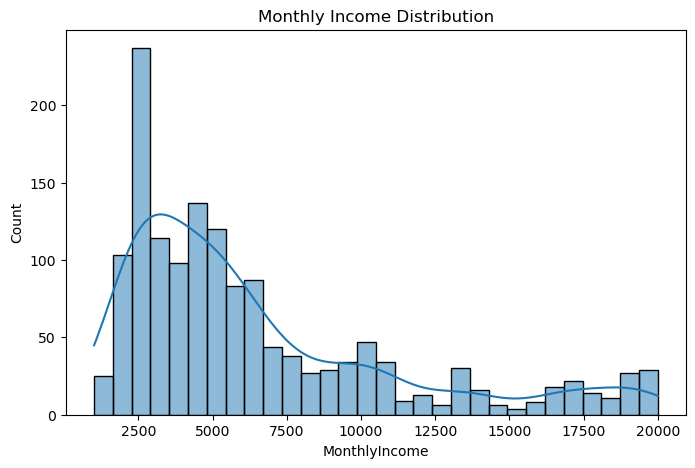

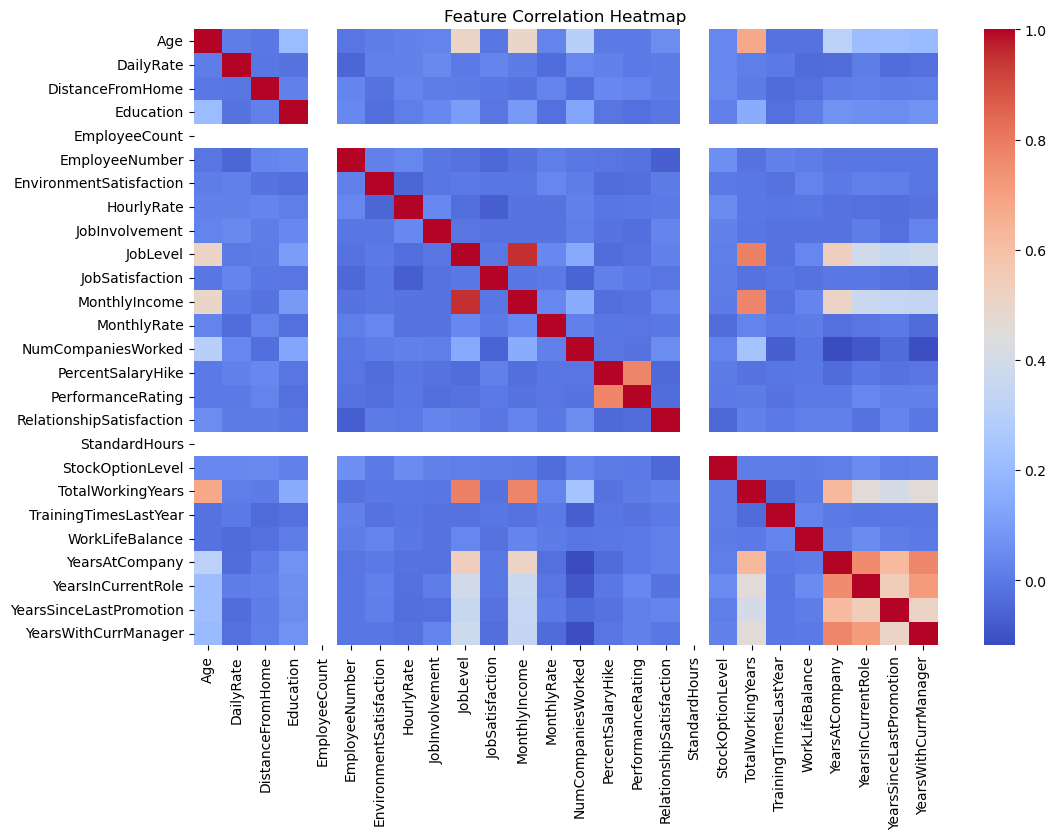


Model Accuracy: 0.8707482993197279

Confusion Matrix:
[[252   3]
 [ 35   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.57      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.72      0.55      0.55       294
weighted avg       0.84      0.87      0.83       294



In [3]:
# HR Attrition Analysis Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# 1 LOAD DATASET
# -----------------------------
import pandas as pd

df = pd.read_csv(r"C:\Users\a13sy\Downloads\archive\WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.head())

print("Dataset Loaded Successfully")
print(df.head())

# -----------------------------
# 2 BASIC DATA INFORMATION
# -----------------------------

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# -----------------------------
# 3 ATTRITION COUNT
# -----------------------------

print("\nAttrition Count:")
print(df["Attrition"].value_counts())

sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition Distribution")
plt.show()

# -----------------------------
# 4 DEPARTMENT ATTRITION
# -----------------------------

plt.figure(figsize=(8,5))
sns.countplot(x="Department", hue="Attrition", data=df)
plt.title("Attrition by Department")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 5 SALARY DISTRIBUTION
# -----------------------------

plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyIncome"], bins=30, kde=True)
plt.title("Monthly Income Distribution")
plt.show()

# -----------------------------
# 6 CORRELATION HEATMAP
# -----------------------------

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# -----------------------------
# 7 DATA PREPROCESSING
# -----------------------------

# Convert categorical to numeric

label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

# Target Variable
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# -----------------------------
# 8 TRAIN TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 9 MACHINE LEARNING MODEL
# -----------------------------

model = RandomForestClassifier()

model.fit(X_train, y_train)

# -----------------------------
# 10 PREDICTION
# -----------------------------

y_pred = model.predict(X_test)

# -----------------------------
# 11 MODEL EVALUATION
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))